# Solving the Traveling Salesman  Problem using Local Search

Points: 10

## The Traveling Salesman Problem

Problem definition (see [TSP on Wikipedia](https://en.wikipedia.org/wiki/Travelling_salesman_problem)):

* __Goal:__ Find the shortest tour visiting each of $n$ cities exactly once and returning back to the starting city. Given are pairwise distances between cities, where $d_{i,j}$ is the distance from city $i$ to city $j$.

* __State space:__ Each state represents a tour. The cities are numbered and a tour can be expressed as vector  $\pi$ with the order in which the cities are visited (a [permutation](https://en.wikipedia.org/wiki/Permutation)). That is, $\pi(1)$ is the index of the first city to visit, $\pi(2)$ the index of the second, and so on.

* __Objective function:__ Minimize the tour length. The optimization problem is to find the optimal tour $\pi^*$ through the $n$ cities and returning to the starting city:

  > minimize: $\mathrm{tourlength}(\pi) = d_{\pi(n),\pi(1)} + \sum_{i = 1}^{n-1} d_{\pi(i),\pi(i+1)}$
  >
  > subject to: $\pi \ \text{is a valid permutation vector}$

* __Local moves:__ Exchange two cities in the order.

## Helper functions

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

np.set_printoptions(precision = 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# make the results repeatable
np.random.seed(1234)

In [13]:
def random_tour(n):
    """Create a random tour"""

    tour = list(range(n))
    random.shuffle(tour)
    return(tour)

random_tour(10)

[0, 6, 7, 9, 5, 3, 4, 1, 8, 2]

In [14]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

def random_tsp(n):
    """
    Create a random (Euclidean) traveling salesman problem. Choose n points randomly in a 1 x 1 unit square and calulates a
    pairwise Euclidean distance matrix.
    """

    pos = pd.DataFrame({
        "x" : np.random.uniform(size = n),
        "y" : np.random.uniform(size = n)
    })

    dist = squareform(pdist(pos))

    return({"pos": pos, "dist": dist})

tsp = random_tsp(10)

print(f"Positions:\n{tsp['pos']}")
print(f"Distance matrix:\n{pd.DataFrame(tsp['dist'])})")

Positions:
     x    y
0 0.19 0.36
1 0.62 0.50
2 0.44 0.68
3 0.79 0.71
4 0.78 0.37
5 0.27 0.56
6 0.28 0.50
7 0.80 0.01
8 0.96 0.77
9 0.88 0.88
Distance matrix:
     0    1    2    3    4    5    6    7    8    9
0 0.00 0.45 0.41 0.69 0.59 0.22 0.17 0.70 0.87 0.86
1 0.45 0.00 0.26 0.27 0.20 0.35 0.35 0.52 0.43 0.46
2 0.41 0.26 0.00 0.35 0.46 0.21 0.24 0.76 0.53 0.48
3 0.69 0.27 0.35 0.00 0.34 0.53 0.55 0.70 0.18 0.19
4 0.59 0.20 0.46 0.34 0.00 0.54 0.52 0.36 0.44 0.52
5 0.22 0.35 0.21 0.53 0.54 0.00 0.06 0.76 0.72 0.68
6 0.17 0.35 0.24 0.55 0.52 0.06 0.00 0.72 0.73 0.71
7 0.70 0.52 0.76 0.70 0.36 0.76 0.72 0.00 0.77 0.87
8 0.87 0.43 0.53 0.18 0.44 0.72 0.73 0.77 0.00 0.14
9 0.86 0.46 0.48 0.19 0.52 0.68 0.71 0.87 0.14 0.00)


In [15]:
def tour_length(tsp, tour):
    """Caclulate the length of a tour, i.e., the objective function."""

    # make sure tour is a Python list (not an array or a numpy.array)
    if not isinstance(tour, list): tour = tour.tolist()

    tl = 0
    dist = tsp["dist"]

    for i in range(len(tour)-1):
        tl += dist[tour[i], tour[i+1]]

    tl += dist[tour[-1], tour[0]]

    return(tl)

tour = random_tour(10)
tour_length(tsp, tour)

np.float64(4.6961479011892955)

Tour length: 4.7


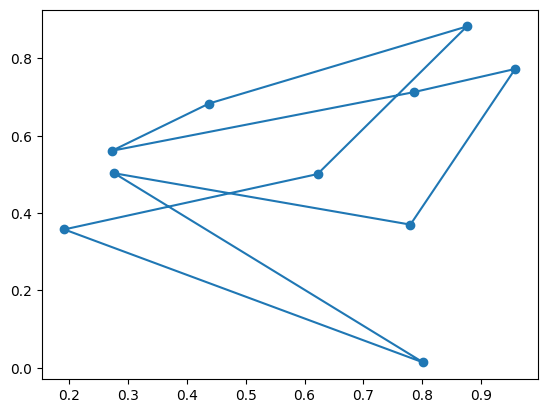

In [16]:
def show_tsp(tsp, tour = None):
    """display the traveling salesman problem and a tour."""

    pos = tsp["pos"]

    plt.scatter(pos["x"], pos["y"])

    if tour is not None:
        # make sure tour is a Python list (not an array or a numpy.array)
        if not isinstance(tour, list): tour = tour.tolist()

        print(f"Tour length: {round(tour_length(tsp, tour), 2)}")

        pos_ = pos.reindex(tour)
        pos_ = pd.concat([pos_, pos_.head(1)])
        plt.plot(pos_["x"], pos_["y"])

    plt.show()

show_tsp(tsp, tour)

## Use R to find a solution

Load rpy2, make sure the R [TSP package](https://CRAN.R-project.org/package=TSP) is installed and prepare the distance matrix.

In [17]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [18]:
%%R
    if (!"TSP" %in% rownames(installed.packages())) {
    install.packages("TSP", repos="http://cran.us.r-project.org")
    }

    if (!"microbenchmark" %in% rownames(installed.packages())) {
    install.packages("microbenchmark", repos="http://cran.us.r-project.org")
    }

In [19]:
d = tsp["dist"]

Solve the TSP using [`solve_TSP`](https://www.rdocumentation.org/packages/TSP/versions/1.1-10/topics/solve_TSP) with the default heuristic. Note that 2-opt is steepest ascend hill climbing with exchanging two cities. `rep = 10` means 10 random restarts.

In [23]:
from python_tsp.exact import solve_tsp_dynamic_programming
import numpy as np

# d là ma trận khoảng cách numpy
permutation, distance = solve_tsp_dynamic_programming(d)
print("Tour:", permutation)
print("Distance:", distance)


Tour: [0, 6, 5, 2, 9, 8, 3, 1, 4, 7]
Distance: 2.763573577757701


Tour length: 4.7


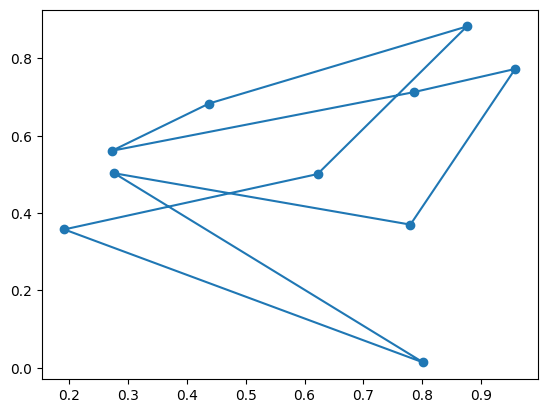

In [24]:
show_tsp(tsp, tour)

How long does it take to solve the problem?

In [27]:
from python_tsp.exact import solve_tsp_dynamic_programming
import numpy as np
import time

# d là ma trận khoảng cách numpy
repeats = 10
times = []

for _ in range(repeats):
    start = time.time()
    permutation, distance = solve_tsp_dynamic_programming(d)
    end = time.time()
    times.append(end - start)

print("Tour:", permutation)
print("Distance:", distance)
print("Times (s):", times)
print("Average time:", sum(times)/repeats)


Tour: [0, 6, 5, 2, 9, 8, 3, 1, 4, 7]
Distance: 2.763573577757701
Times (s): [0.016953229904174805, 0.011003255844116211, 0.011966943740844727, 0.009942054748535156, 0.07698750495910645, 0.007976531982421875, 0.00901341438293457, 0.009203195571899414, 0.009215354919433594, 0.009348630905151367]
Average time: 0.017161011695861816


## Steepest-ascend Hill Climbing Search [3 Points]

Calculate the objective function for all local moves (move each queen within its column) and always choose the best among all local moves.

In [2]:
# Code goes here
import numpy as np
def path_length(path, distance_matrix):
    """
    Hàm mục tiêu: Tổng độ dài của hành trình (càng nhỏ càng tốt)
    path: danh sách thứ tự các thành phố, ví dụ [0, 2, 1, 3]
    distance_matrix: ma trận khoảng cách giữa các thành phố
    """
    total_distance = 0
    for i in range(len(path) - 1):
        total_distance += distance_matrix[path[i]][path[i + 1]]
    # Quay lại thành phố xuất phát
    total_distance += distance_matrix[path[-1]][path[0]]
    return total_distance

# -------------------------------
# Sinh các lời giải lân cận (neighbors)
# -------------------------------
def generate_neighbors(path):
    """
    Sinh các lời giải lân cận bằng cách hoán đổi vị trí 2 thành phố trong hành trình.
    """
    neighbors = []
    n = len(path)
    for i in range(n):
        for j in range(i + 1, n):
            neighbor = path.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors

# -------------------------------
# Thuật toán Steepest Ascent Hill Climbing cho TSP
# -------------------------------
def steepest_ascent_hill_climbing_tsp(distance_matrix, max_steps=1000):
    n = len(distance_matrix)
    
    # Khởi tạo ngẫu nhiên hành trình ban đầu
    current_path = np.random.permutation(n).tolist()
    current_cost = path_length(current_path, distance_matrix)
    
    for step in range(max_steps):
        neighbors = generate_neighbors(current_path)
        
        # Tìm neighbor tốt nhất (ngắn nhất)
        best_neighbor = min(neighbors, key=lambda p: path_length(p, distance_matrix))
        best_cost = path_length(best_neighbor, distance_matrix)
        
        # Nếu không có cải thiện thì dừng (local minimum)
        if best_cost >= current_cost:
            break
        
        # Cập nhật hành trình tốt hơn
        current_path, current_cost = best_neighbor, best_cost
    
    return current_path, current_cost

# -------------------------------
# Ví dụ chạy thử
# -------------------------------
# Giả sử có 5 thành phố (ma trận đối xứng)
distance_matrix = np.array([
    [0, 2, 9, 10, 7],
    [2, 0, 6, 4, 3],
    [9, 6, 0, 8, 5],
    [10, 4, 8, 0, 6],
    [7, 3, 5, 6, 0]
])

best_path, best_cost = steepest_ascent_hill_climbing_tsp(distance_matrix)
print("Hành trình tốt nhất tìm được:", best_path)
print("Tổng độ dài hành trình:", best_cost)

Hành trình tốt nhất tìm được: [0, 2, 4, 3, 1]
Tổng độ dài hành trình: 26


## Steepest-ascend Hill Climbing Search with Random Restarts [1 Point]

Steepest-ascend with random restarts.

In [7]:
# Code goes here
import numpy as np

# -----------------------------------
# Hàm mục tiêu: Tổng độ dài hành trình
# -----------------------------------
def objective(path, distance_matrix):
    total_distance = 0
    for i in range(len(path) - 1):
        total_distance += distance_matrix[path[i]][path[i + 1]]
    total_distance += distance_matrix[path[-1]][path[0]]
    return total_distance

# -----------------------------------
# Sinh các lời giải lân cận
# -----------------------------------
def generate_neighbors(path):
    neighbors = []
    n = len(path)
    for i in range(n):
        for j in range(i + 1, n):
            neighbor = path.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors

# -----------------------------------
# Hill Climbing - Steepest Ascent
# -----------------------------------
def steepest_ascent_hill_climbing(distance_matrix, max_steps=1000):
    n = len(distance_matrix)
    current_path = np.random.permutation(n).tolist()
    current_cost = objective(current_path, distance_matrix)
    
    for step in range(max_steps):
        neighbors = generate_neighbors(current_path)
        best_neighbor = min(neighbors, key=lambda p: objective(p, distance_matrix))
        best_cost = objective(best_neighbor, distance_matrix)
        
        if best_cost >= current_cost:
            break
        
        current_path, current_cost = best_neighbor, best_cost
    
    return current_path, current_cost

# -----------------------------------
# Hill Climbing có Random Restarts
# -----------------------------------
def steepest_ascent_with_random_restarts(distance_matrix, restarts=10, max_steps=1000):
    best_solution = None
    best_cost = float('inf')
    
    for i in range(restarts):
        solution, cost = steepest_ascent_hill_climbing(distance_matrix, max_steps)
        if cost < best_cost:
            best_cost = cost
            best_solution = solution
        print(f"Lần khởi tạo {i+1}: tổng độ dài = {cost}")
    
    return best_solution, best_cost

# -----------------------------------
# Ví dụ chạy thử
# -----------------------------------
distance_matrix = np.array([
    [0, 2, 9, 10, 7],
    [2, 0, 6, 4, 3],
    [9, 6, 0, 8, 5],
    [10, 4, 8, 0, 6],
    [7, 3, 5, 6, 0]
])

solution, cost = steepest_ascent_with_random_restarts(distance_matrix, restarts=10)
print("\nHành trình tốt nhất:", solution)
print("Tổng độ dài hành trình:", cost)


Lần khởi tạo 1: tổng độ dài = 26
Lần khởi tạo 2: tổng độ dài = 26
Lần khởi tạo 3: tổng độ dài = 26
Lần khởi tạo 4: tổng độ dài = 26
Lần khởi tạo 5: tổng độ dài = 26
Lần khởi tạo 6: tổng độ dài = 26
Lần khởi tạo 7: tổng độ dài = 26
Lần khởi tạo 8: tổng độ dài = 26
Lần khởi tạo 9: tổng độ dài = 26
Lần khởi tạo 10: tổng độ dài = 26

Hành trình tốt nhất: [2, 4, 3, 1, 0]
Tổng độ dài hành trình: 26


## Stochastic Hill Climbing [1 Points]

Chooses randomly from among all uphill moves.

In [8]:
# Code goes here
import numpy as np
import random

# -----------------------------------
# Hàm mục tiêu: tổng độ dài hành trình
# -----------------------------------
def objective(path, distance_matrix):
    total_distance = 0
    for i in range(len(path) - 1):
        total_distance += distance_matrix[path[i]][path[i + 1]]
    total_distance += distance_matrix[path[-1]][path[0]]  # quay lại điểm đầu
    return total_distance

# -----------------------------------
# Sinh các lời giải lân cận
# -----------------------------------
def generate_neighbors(path):
    neighbors = []
    n = len(path)
    for i in range(n):
        for j in range(i + 1, n):
            neighbor = path.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors

# -----------------------------------
# Stochastic Hill Climbing cho TSP
# -----------------------------------
def stochastic_hill_climbing_tsp(distance_matrix, max_steps=1000):
    n = len(distance_matrix)
    current_path = np.random.permutation(n).tolist()
    current_cost = objective(current_path, distance_matrix)
    
    for step in range(max_steps):
        neighbors = generate_neighbors(current_path)
        
        # Lọc ra các bước đi tốt hơn hiện tại
        better_neighbors = [
            p for p in neighbors if objective(p, distance_matrix) < current_cost
        ]
        
        # Nếu không còn hướng đi tốt hơn → local minimum
        if not better_neighbors:
            break
        
        # Chọn ngẫu nhiên một bước đi tốt hơn
        current_path = random.choice(better_neighbors)
        current_cost = objective(current_path, distance_matrix)
    
    return current_path, current_cost

# -----------------------------------
# Ví dụ chạy thử
# -----------------------------------
distance_matrix = np.array([
    [0, 2, 9, 10, 7],
    [2, 0, 6, 4, 3],
    [9, 6, 0, 8, 5],
    [10, 4, 8, 0, 6],
    [7, 3, 5, 6, 0]
])

solution, cost = stochastic_hill_climbing_tsp(distance_matrix)
print("Hành trình tìm được:", solution)
print("Tổng độ dài hành trình:", cost)


Hành trình tìm được: [2, 4, 3, 1, 0]
Tổng độ dài hành trình: 26


## Stochastic Hill Climbing (First-choice) [1 Point]

First-choice hill climbing is a type of stochastic hill climbing that generates one random local neighbor at a time and accept it if it has a better objective function value than the current state.

### Local Moves
I implement the following three different local move strategies:
* Swap two random cities.
* Swap two neighboring cities.
* Reverse the subtour between two cities.

In [38]:
def move_swap(tour):
    new_tour = tour.copy()

    # np.random.randint is inclusive lower limit and exclusive upper limit
    [a, b] = np.random.randint(0, len(tour), 2)
    #print(f"a={a}, b={b}")

    new_tour[a] = tour[b]
    new_tour[b] = tour[a]
    return(new_tour)

print(move_swap(list(range(10))))
print(move_swap(list(range(10))))
print(move_swap(list(range(10))))

[0, 1, 9, 3, 4, 5, 6, 7, 8, 2]
[0, 1, 2, 3, 7, 5, 6, 4, 8, 9]
[0, 1, 3, 2, 4, 5, 6, 7, 8, 9]


In [39]:
def move_swap_neighbors(tour):
    new_tour = tour.copy()

    a = np.random.randint(0, len(tour)-1, 1)[0]
    if a > 0: b = a+1
    else: b = len(tour)-1
    #print(f"a={a}, b={b}")

    new_tour[a] = tour[b]
    new_tour[b] = tour[a]
    return(new_tour)

print(move_swap_neighbors(list(range(10))))
print(move_swap_neighbors(list(range(10))))
print(move_swap_neighbors(list(range(10))))

[0, 1, 2, 3, 4, 6, 5, 7, 8, 9]
[0, 1, 2, 3, 4, 6, 5, 7, 8, 9]
[0, 2, 1, 3, 4, 5, 6, 7, 8, 9]


In [40]:
def move_reverse(tour):
    new_tour = tour.copy()

    ab = np.random.randint(0, len(tour)+1, 2)
    ab.sort()
    #print(f"a={ab[0]}, b={ab[1]}")

    new_tour[ab[0]:ab[1]] = new_tour[ab[0]:ab[1]][::-1]
    return(new_tour)

print(move_reverse(list(range(10))))
print(move_reverse(list(range(10))))
print(move_reverse(list(range(10))))

[7, 6, 5, 4, 3, 2, 1, 0, 8, 9]
[3, 2, 1, 0, 4, 5, 6, 7, 8, 9]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Search Algorithm

I don't know what the optimal tour is so I run the algorithm for at most `max_steps` steps, and stop if there is no improvement for at least `stop_after` steps.

In [41]:
def FCSHC(tsp, tour = None, local_move_method = move_swap,
         max_steps = 1000000, stop_after = 1000, verbose = True, keep_history = False):

    n = len(tsp['pos'])

    if keep_history: history = list()

    # 1. initialize current tour
    # current tour = initial tour (random if no tour is given)
    if not tour is None:
        current_tour = tour
    else:
        current_tour = random_tour(n)


    # initial tour length
    current_length = tour_length(tsp, current_tour)
    if verbose: print(f"initial tour length: {current_length}")

    # step when we last improved the length
    last_improvement_step = 0

    # 2. repeat local moves
    for step in range(max_steps):

        new_tour = local_move_method(current_tour)
        new_length = tour_length(tsp, new_tour)

        # check if the new tour is better
        if new_length < current_length:
            current_tour = new_tour
            current_length = new_length
            last_improvement_step = step
            if verbose: print(f"step: {step} - new tour length: {current_length}")

        if keep_history: history.append(current_length)

        # stop if we did not improve for stop_after steps
        if step - last_improvement_step > stop_after:
            if verbose: print(f"step: {step} - no improvement for {stop_after} steps.")
            break


    if keep_history: return(current_tour, history)
    return(current_tour)

### Comparison of Local Move Strategies Using a Single Problem

Tour length: 4.13


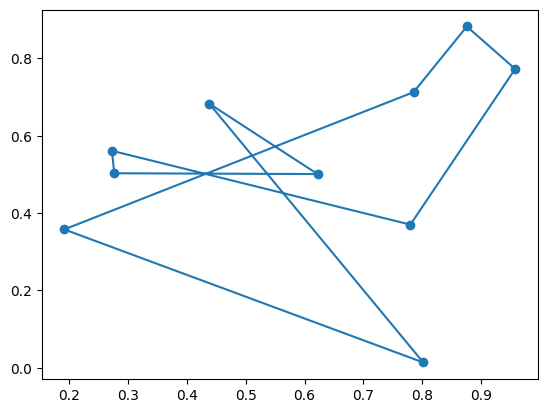

In [42]:
initial_tour = random_tour(len(tsp['pos']))
show_tsp(tsp, initial_tour)

initial tour length: 4.13014127576352
step: 4 - new tour length: 4.117768049318954
step: 7 - new tour length: 4.115626262229778
step: 8 - new tour length: 3.5301434475129363
step: 12 - new tour length: 3.322136570530473
step: 38 - new tour length: 3.1369228864473633
step: 67 - new tour length: 3.0654892705830936
step: 78 - new tour length: 2.786516989419932
step: 1079 - no improvement for 1000 steps.
CPU times: total: 15.6 ms
Wall time: 16.1 ms
Tour length: 2.79


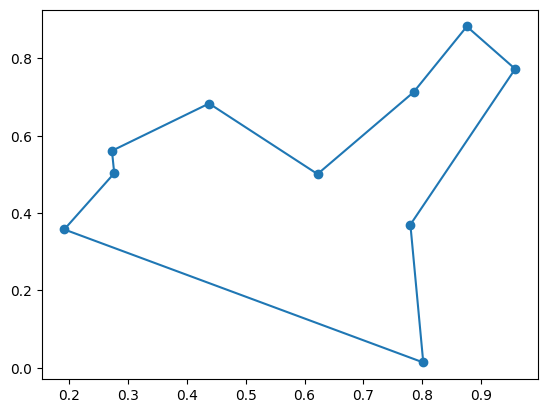

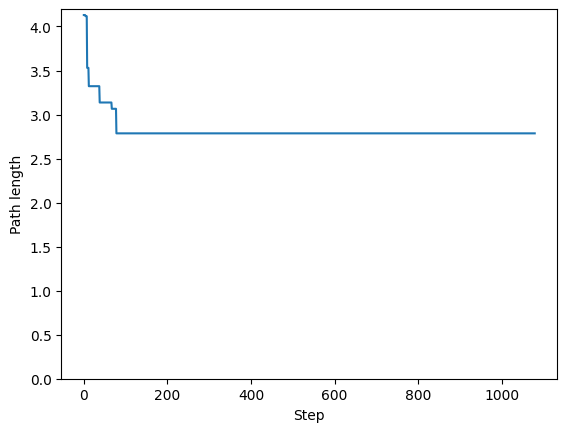

In [43]:
%time tour, history_swap = FCSHC(tsp, initial_tour, local_move_method = move_swap, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history_swap)), history_swap)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

initial tour length: 4.13014127576352
step: 4 - new tour length: 3.7834200158636473
step: 7 - new tour length: 3.771046789419082
step: 13 - new tour length: 3.6673813069163073
step: 15 - new tour length: 3.6349094704197142
step: 18 - new tour length: 3.449992920290663
step: 19 - new tour length: 3.4444051996859906
step: 22 - new tour length: 3.2403716435166237
step: 40 - new tour length: 3.153223959037089
step: 1041 - no improvement for 1000 steps.
CPU times: total: 15.6 ms
Wall time: 14 ms
Tour length: 3.15


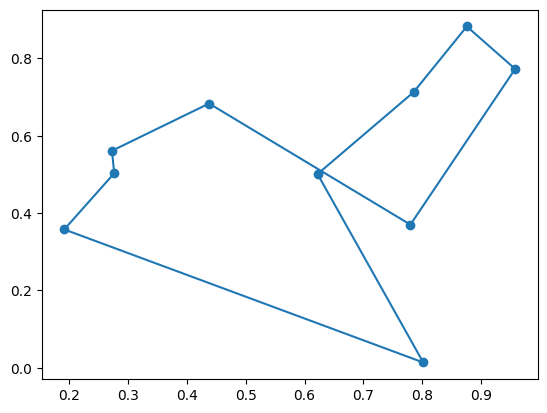

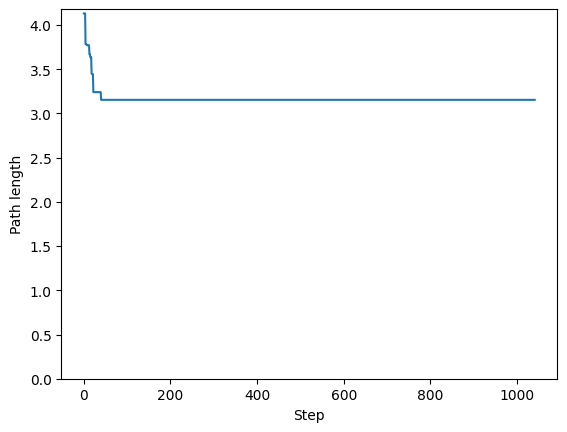

In [44]:
%time tour, history_swap_neighbors = FCSHC(tsp, initial_tour, local_move_method = move_swap_neighbors, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history_swap_neighbors)), history_swap_neighbors)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

initial tour length: 4.13014127576352
step: 16 - new tour length: 3.463471895738597
step: 20 - new tour length: 3.187850320292329
step: 28 - new tour length: 3.129680908482122
step: 30 - new tour length: 2.8736646738994662
step: 47 - new tour length: 2.786516989419932
step: 1048 - no improvement for 1000 steps.
CPU times: total: 31.2 ms
Wall time: 14.6 ms
Tour length: 2.79


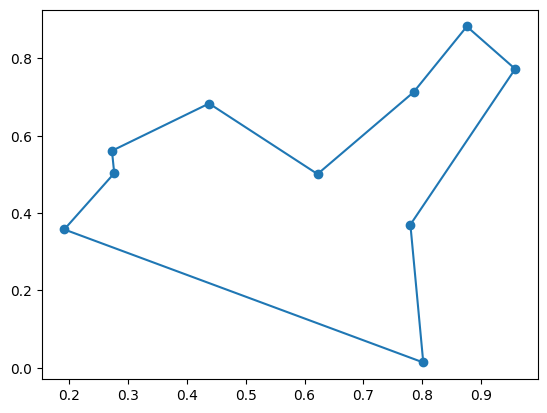

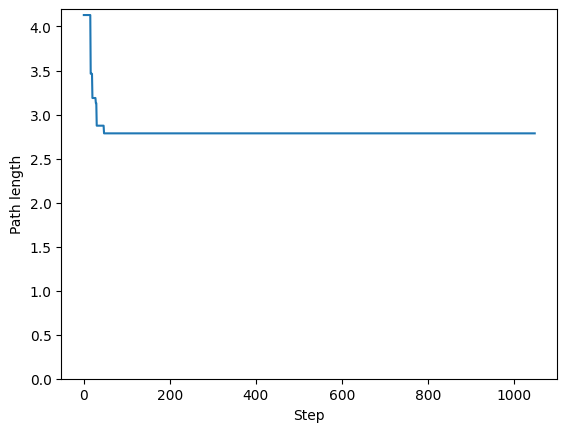

In [45]:
%time tour, history_reverse = FCSHC(tsp, initial_tour, local_move_method = move_reverse, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history_reverse)), history_reverse)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

All three learning curves

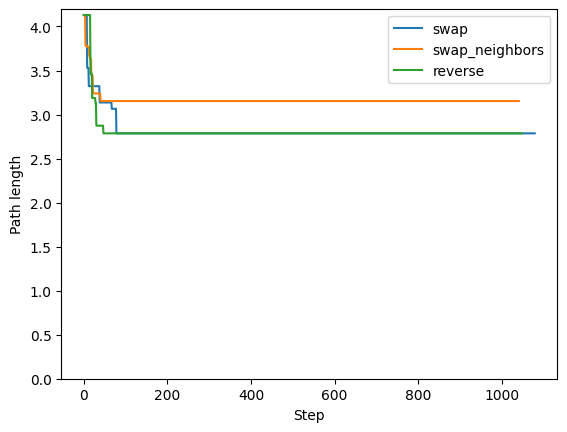

In [46]:
plt.plot(range(len(history_swap)), history_swap, label = "swap")
plt.plot(range(len(history_swap_neighbors)), history_swap_neighbors, label = "swap_neighbors")
plt.plot(range(len(history_reverse)), history_reverse, label = "reverse")
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.legend()
plt.show()

### Comparison of Local Move Strategies

We compare the local move strategies using 100 random problems.

In [47]:
N = 100 # replications
n = 20 # number of cities

results = {
    'swap' : np.zeros(shape = [N]),
    'swap_neighbors' : np.zeros(shape = [N]),
    'reverse' : np.zeros(shape = [N])
}

for i in range(N):
    tsp_test = random_tsp(n)
    initial_tour = random_tour(n)

    results['swap'][i] = tour_length(tsp_test,
        FCSHC(tsp_test, initial_tour, local_move_method = move_swap, verbose = False))

    results['swap_neighbors'][i] = tour_length(tsp_test,
        FCSHC(tsp_test, initial_tour, local_move_method = move_swap_neighbors, verbose = False))

    results['reverse'][i] = tour_length(tsp_test,
        FCSHC(tsp_test, initial_tour, local_move_method = move_reverse, verbose = False))

    swap  swap_neighbors  reverse
0   4.65            8.55     3.87
1   4.12            7.66     4.00
2   5.04            7.72     3.36
3   4.66            8.38     4.02
4   4.83            7.56     4.01
..   ...             ...      ...
95  5.05            9.22     4.02
96  4.72            8.30     3.92
97  3.85            8.38     3.85
98  5.20            8.86     3.91
99  3.70            6.79     3.81

[100 rows x 3 columns]
swap             4.63
swap_neighbors   8.11
reverse          3.91
dtype: float64


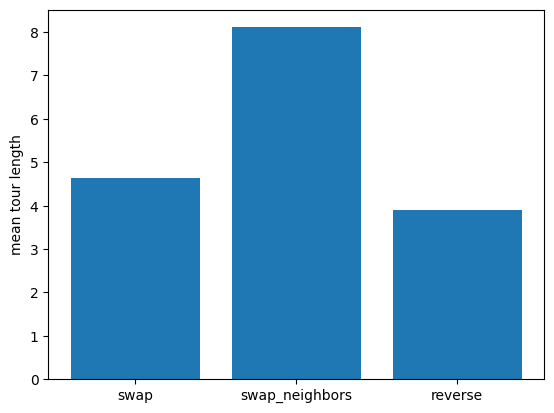

In [48]:
# compare averages
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(results)
print(results)

means = np.mean(results, axis = 0)
print(means)

plt.bar(means.keys(), means)
plt.ylabel("mean tour length")
plt.show()


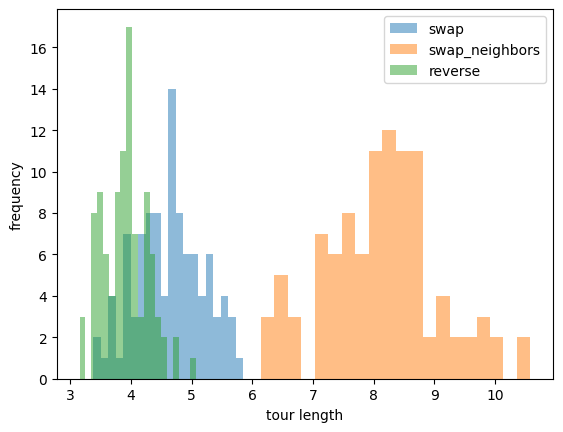

In [49]:
# histogram

plt.hist(results['swap'], bins = 20, alpha = .5)
plt.hist(results['swap_neighbors'], bins = 20, alpha = .5)
plt.hist(results['reverse'], bins = 20, alpha = .5)
plt.xlabel("tour length")
plt.ylabel("frequency")
plt.legend(labels = ["swap", "swap_neighbors", "reverse"])
plt.show()

<Axes: >

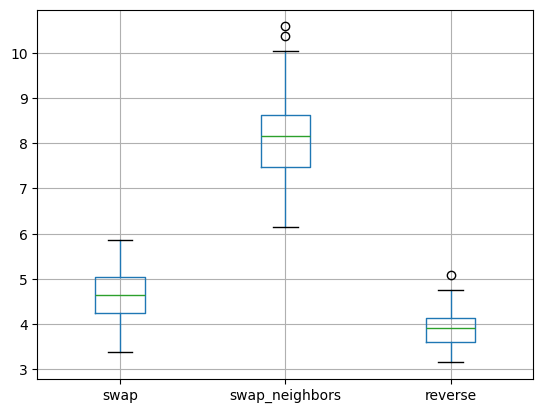

In [50]:
# boxplot (from pandas.DataFrame)

results.boxplot()

In [51]:
# is reverse better than swap?
# perform a paired t-test

from scipy import stats

stats.ttest_rel(results['swap'], results['reverse'])

TtestResult(statistic=np.float64(14.206918792304554), pvalue=np.float64(1.2421801399828943e-25), df=np.int64(99))

## Simulated Annealing [2 Points]

Simulated annealing is a form of stochastic hill climbing that also allows downhill moves with a probability proportional to the temperature. This is done to avoid local optima. The temperature is decreased in every iteration following an annealing schedule.

Finding a good cooling schedule for the problem is the most challenging part of simulated annealing. Some guidance can be found [here](http://what-when-how.com/artificial-intelligence/a-comparison-of-cooling-schedules-for-simulated-annealing-artificial-intelligence/).

The initial temperature $T_0$ should be chosen such that initially any move, no matter how bad, has a high probability of being performed. For $P = exp(-\Delta E/T_0)$ we get a probability of $exp(-1) = 0.37$ if $T_0$ is equal to the worst $\Delta E$. This is typically enough.

For the schedule, $T_t = T_0 \alpha^t$ is popular with $\alpha$ less but close to 1 and $t$ being the time step. Note that this is equivalent to multiplying the current temperature with $\alpha$ at every step.

In [52]:
def schedule(t, T0, alpha):
    return(T0 * alpha ** t)

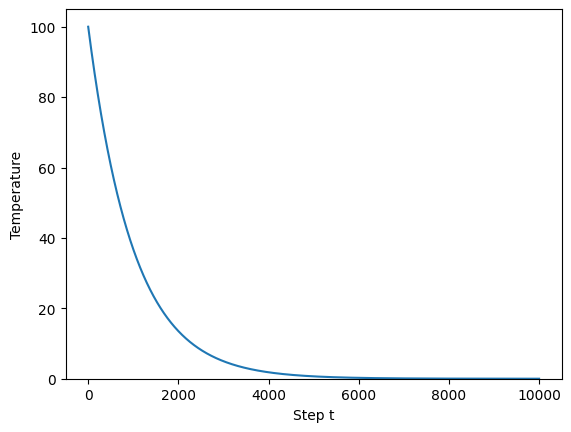

In [53]:
ts = range(0,10000)
plt.plot(ts, [schedule(t, 100, 0.999) for t in ts])
plt.xlabel("Step t")
plt.ylabel("Temperature")
plt.ylim(bottom = 0)
plt.show()

In [54]:
def SA(tsp, tour = None, local_move_method = move_reverse,
         T0 = None, alpha = 0.999, epsilon = 1e-3, verbose = True, keep_history = False):

    n = len(tsp['pos'])

    if keep_history: history = list()

    # 1. initialize current tour
    # current tour = initial tour (random if no tour is given)
    if not tour is None:
        current_tour = tour
    else:
        current_tour = random_tour(n)

    # initial tour length
    current_length = tour_length(tsp, current_tour)
    if verbose: print(f"initial tour length: {current_length:3.3}")

    # use the worst case length. We use the maximal distance for each row of the distance matrix.
    # This may not be a valid tour, but it is an upper limit for deltaE.
    if T0 is None:
        T0 = np.sum(np.amax(tsp["dist"], axis = 0))

    # 2. repeat local moves till temperature is low enough
    T = T0
    t = 0
    while T > epsilon:

        # calculate temperature from schedule
        T = schedule(t, T0, alpha)

        # create random move
        new_tour = local_move_method(current_tour)
        new_length = tour_length(tsp, new_tour)

        deltaE = new_length - current_length

        # check if the new tour is better
        if deltaE < 0 or np.random.rand() < math.exp(-deltaE/T):
            current_tour = new_tour
            current_length = new_length
            if verbose: print(f"step: {t} \t temp: {T:5.3f} \t deltaE: {deltaE:+3.3f} \t new tour length: {current_length:3.3f}")

        if keep_history: history.append(current_length)

        t += 1

    if keep_history: return(current_tour, history)
    return(current_tour)

CPU times: total: 1.22 s
Wall time: 1.21 s
Tour length: 2.76


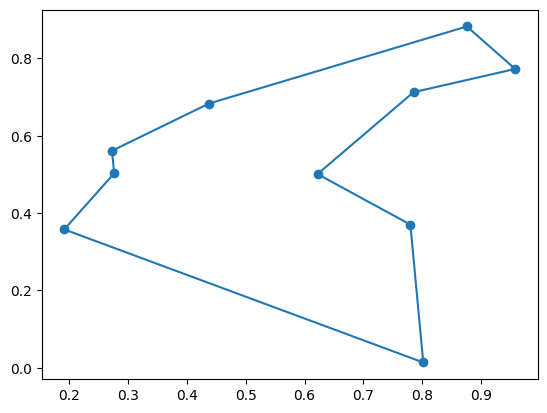

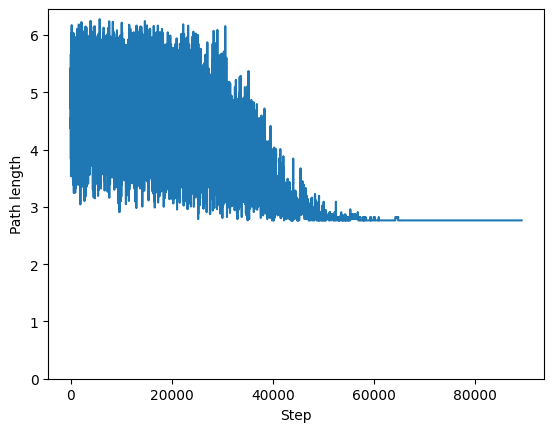

In [55]:
%time tour, history = SA(tsp, local_move_method = move_swap, alpha = 0.9999, verbose = False, keep_history = True)
show_tsp(tsp, tour)

plt.plot(range(len(history)), history)
plt.xlabel("Step")
plt.ylabel("Path length")
plt.ylim(bottom = 0)
plt.show()

## Compare Performance [2 Points]

Use runtime, scalability (number of cities), and best objective function value to compare the algorithms on boards of different sizes.  

For timing you can use the `time` package.

In [56]:
import time

t0 = time.time()
print("Do something")
t1 = time.time()

print(f"This took: {(t1-t0) * 1e3} milliseconds")

Do something
This took: 0.9977817535400391 milliseconds



--- Testing TSP with 5 cities ---
FCSHC_swap: Best tour length = 2.407, Runtime = 12.964 ms
FCSHC_neighbors: Best tour length = 2.407, Runtime = 9.973 ms
FCSHC_reverse: Best tour length = 2.407, Runtime = 10.971 ms
SA_swap: Best tour length = 2.407, Runtime = 1089.087 ms
SA_reverse: Best tour length = 2.407, Runtime = 1118.010 ms

--- Testing TSP with 10 cities ---
FCSHC_swap: Best tour length = 3.126, Runtime = 13.961 ms
FCSHC_neighbors: Best tour length = 3.631, Runtime = 9.974 ms
FCSHC_reverse: Best tour length = 2.765, Runtime = 14.960 ms
SA_swap: Best tour length = 2.765, Runtime = 1363.355 ms
SA_reverse: Best tour length = 2.765, Runtime = 1366.347 ms

--- Testing TSP with 15 cities ---
FCSHC_swap: Best tour length = 3.485, Runtime = 20.976 ms
FCSHC_neighbors: Best tour length = 5.956, Runtime = 12.957 ms
FCSHC_reverse: Best tour length = 3.276, Runtime = 26.935 ms
SA_swap: Best tour length = 3.276, Runtime = 1407.204 ms
SA_reverse: Best tour length = 3.276, Runtime = 1454.604 m

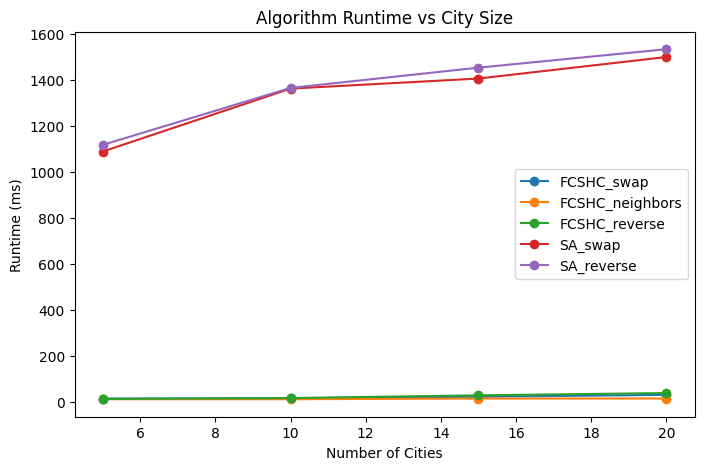

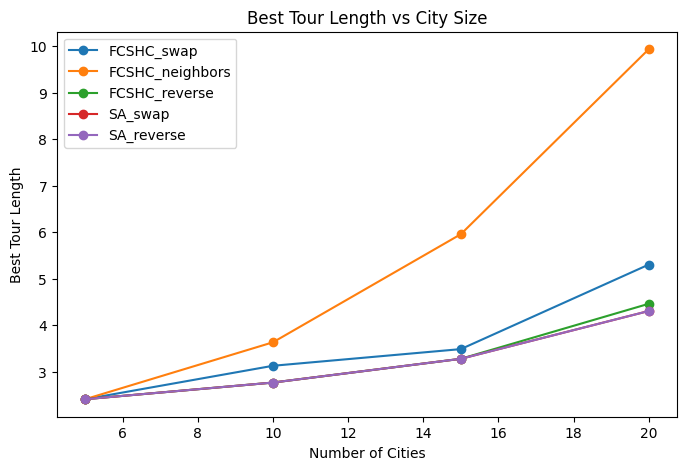

In [57]:
# Code and results go here
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------------
# Giả sử các hàm đã định nghĩa trước:
# - random_tsp(n)
# - random_tour(n)
# - tour_length(tsp, tour)
# - FCSHC(tsp, tour, local_move_method)
# - SA(tsp, tour, local_move_method, alpha)
# - move_swap, move_swap_neighbors, move_reverse
# - show_tsp(tsp, tour) (tuỳ chọn)
# -----------------------------------

# Danh sách thuật toán
algorithms = {
    "FCSHC_swap": lambda tsp, tour: FCSHC(tsp, tour, local_move_method=move_swap, verbose=False),
    "FCSHC_neighbors": lambda tsp, tour: FCSHC(tsp, tour, local_move_method=move_swap_neighbors, verbose=False),
    "FCSHC_reverse": lambda tsp, tour: FCSHC(tsp, tour, local_move_method=move_reverse, verbose=False),
    "SA_swap": lambda tsp, tour: SA(tsp, tour, local_move_method=move_swap, verbose=False, alpha=0.9999),
    "SA_reverse": lambda tsp, tour: SA(tsp, tour, local_move_method=move_reverse, verbose=False, alpha=0.9999)
}

# Các kích thước TSP để test
city_sizes = [5, 10, 15, 20]

# Lưu kết quả
results = []

for n in city_sizes:
    tsp_test = random_tsp(n)
    initial_tour = random_tour(n)
    
    print(f"\n--- Testing TSP with {n} cities ---")
    
    for name, algo in algorithms.items():
        t0 = time.time()
        best_tour = algo(tsp_test, initial_tour)
        t1 = time.time()
        
        runtime_ms = (t1 - t0) * 1e3
        best_length = tour_length(tsp_test, best_tour)
        
        print(f"{name}: Best tour length = {best_length:.3f}, Runtime = {runtime_ms:.3f} ms")
        
        results.append({
            "Algorithm": name,
            "Num_Cities": n,
            "Best_Length": best_length,
            "Runtime_ms": runtime_ms
        })

# Chuyển kết quả sang DataFrame để dễ phân tích
df_results = pd.DataFrame(results)
print("\nSummary Table:")
print(df_results)

# -----------------------------------
# Biểu đồ Runtime vs Number of Cities
plt.figure(figsize=(8,5))
for name in algorithms.keys():
    runtimes = df_results[df_results["Algorithm"] == name]["Runtime_ms"]
    plt.plot(city_sizes, runtimes, marker='o', label=name)
plt.xlabel("Number of Cities")
plt.ylabel("Runtime (ms)")
plt.title("Algorithm Runtime vs City Size")
plt.legend()
plt.show()

# Biểu đồ Best Tour Length vs Number of Cities
plt.figure(figsize=(8,5))
for name in algorithms.keys():
    lengths = df_results[df_results["Algorithm"] == name]["Best_Length"]
    plt.plot(city_sizes, lengths, marker='o', label=name)
plt.xlabel("Number of Cities")
plt.ylabel("Best Tour Length")
plt.title("Best Tour Length vs City Size")
plt.legend()
plt.show()


## Bonus: Genetic Algorithm [+1 Point]

Best tour: [np.int32(17), np.int32(1), np.int32(14), np.int32(10), np.int32(16), np.int32(15), np.int32(7), np.int32(5), np.int32(2), np.int32(19), np.int32(11), np.int32(4), np.int32(12), np.int32(18), np.int32(6), np.int32(3), np.int32(9), np.int32(13), np.int32(0), np.int32(8)]
Best tour length: 5.477280713345997


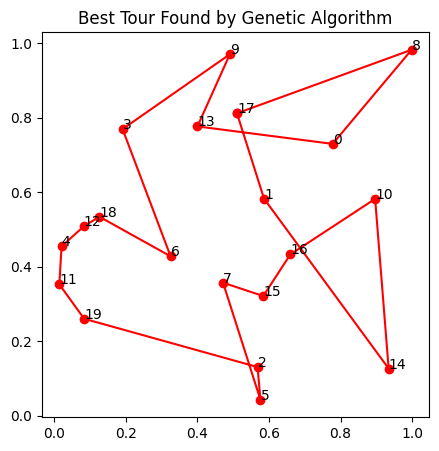

In [24]:
# Code goes here
import numpy as np
import random
import matplotlib.pyplot as plt

# ===============================
# 1. Sinh dữ liệu TSP ngẫu nhiên
# ===============================
def random_tsp(n):
    x = np.random.rand(n)
    y = np.random.rand(n)
    d = np.sqrt((x[:, None] - x[None, :])**2 + (y[:, None] - y[None, :])**2)
    return {"x": x, "y": y, "d": d}

# ===============================
# 2. Các hàm phụ
# ===============================
def random_tour(n):
    return list(np.random.permutation(n))

def tour_length(tsp, tour):
    d = tsp["d"]
    total = 0
    for i in range(len(tour) - 1):
        total += d[tour[i]][tour[i + 1]]
    total += d[tour[-1]][tour[0]]  # quay lại điểm đầu
    return total

def tournament_selection(population, tsp, k=3):
    selected = random.sample(population, k)
    selected = sorted(selected, key=lambda t: tour_length(tsp, t))
    return selected[0]

def order_crossover(p1, p2):
    n = len(p1)
    a, b = sorted(np.random.choice(range(n), 2, replace=False))
    child = [-1] * n
    child[a:b] = p1[a:b]
    pos = b
    for city in p2:
        if city not in child:
            if pos >= n:
                pos = 0
            child[pos] = city
            pos += 1
    return child

def swap_mutation(tour):
    a, b = sorted(np.random.choice(range(len(tour)), 2, replace=False))
    tour[a], tour[b] = tour[b], tour[a]
    return tour

# ===============================
# 3. Thuật toán di truyền (GA)
# ===============================
def GA_TSP(tsp, population_size=50, num_generations=200, mutation_rate=0.1):
    n = len(tsp["d"])
    population = [random_tour(n) for _ in range(population_size)]

    best_tour = min(population, key=lambda t: tour_length(tsp, t))
    best_length = tour_length(tsp, best_tour)

    for gen in range(num_generations):
        new_population = []

        for i in range(0, population_size, 2):
            p1 = tournament_selection(population, tsp)
            p2 = tournament_selection(population, tsp)

            child1 = order_crossover(p1, p2)
            child2 = order_crossover(p2, p1)

            if np.random.rand() < mutation_rate:
                child1 = swap_mutation(child1)
            if np.random.rand() < mutation_rate:
                child2 = swap_mutation(child2)

            new_population.extend([child1, child2])

        population = new_population

        current_best = min(population, key=lambda t: tour_length(tsp, t))
        current_length = tour_length(tsp, current_best)

        if current_length < best_length:
            best_tour = current_best
            best_length = current_length

    return best_tour

# ===============================
# 4. Hàm vẽ tour (tuỳ chọn)
# ===============================
def show_tsp(tsp, tour):
    x, y = tsp["x"], tsp["y"]
    path_x = [x[i] for i in tour + [tour[0]]]
    path_y = [y[i] for i in tour + [tour[0]]]
    plt.figure(figsize=(5, 5))
    plt.plot(path_x, path_y, 'o-r')
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.text(xi, yi, str(i))
    plt.title("Best Tour Found by Genetic Algorithm")
    plt.show()

# ===============================
# 5. Chạy thử
# ===============================
n = 20
tsp_test = random_tsp(n)

best_tour = GA_TSP(tsp_test, population_size=50, num_generations=200, mutation_rate=0.2)
print("Best tour:", best_tour)
print("Best tour length:", tour_length(tsp_test, best_tour))
show_tsp(tsp_test, best_tour)
